In [1]:
# Notebook 3 — Ablation study

import os, json, copy, time
import torch, torch.nn as nn
import pandas as pd
import numpy as np
from pathlib import Path

from data_utils import load_graphs, attach_labels_and_noisy, build_loaders_by_train_val_paths  # or your existing loaders
from train_loop import train, evaluate
from model import QEMGraphTransformer  # baseline model


In [2]:
import json, os, pickle
import numpy as np
from tqdm.notebook import tqdm
import pandas as pd

import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import qiskit.circuit.random
import torch, random
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn as nn

import numpy as np
import json, os, pickle
from tqdm import tqdm
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from qiskit import QuantumCircuit

import sys
from mlp import encode_data, encode_data_v2_ecr

In [3]:
def check_f(f, f_ext, step_indices):
    return f.endswith(f_ext) and any([f"step_%02d"%step_index in f for step_index in step_indices])

def load_circuits(data_dir, step_indices, f_ext='.pk'):
    Js = []
    circuits = []
    data_paths = []
    data_files = sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if check_f(f, f_ext, step_indices)])
    for data_file in tqdm(data_files, leave=True):
        for entry in pickle.load(open(data_file, 'rb')):
            Js.append(entry['J'])
            circuits.append(entry['circuit'])
        data_paths.append(data_file[3:])
    return data_paths, circuits, Js

In [4]:
data_paths, circuits, Js = load_circuits('../../tutorials/data/ising_zne_hardware/100q_brisbane/', list(range(1, 11)))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:38<00:00, 13.07it/s]


In [5]:
for step_index in [1]:
    with open('../../tutorials/zne_mitigated/twirl_100q_brisbane/step%02d.json'%step_index, 'r') as file:
        loaded = json.load(file)
    noise_factor_1 = np.array(loaded['noise_factor_1'])
    noise_factor_3 = np.array(loaded['noise_factor_3'])

for step_index in tqdm([2, 3, 4, 5, 6, 7, 8, 9, 10]):
    with open('../../tutorials/zne_mitigated/twirl_100q_brisbane/step%02d.json'%step_index, 'r') as file:
        loaded = json.load(file)
    noise_factor_1 = np.concatenate([noise_factor_1, loaded['noise_factor_1']])
    noise_factor_3 = np.concatenate([noise_factor_3, loaded['noise_factor_3']])

noise_factor_1_tw_avg = noise_factor_1.reshape(noise_factor_1.shape[0], 5, 5).mean(axis=-1)
noise_factor_3_tw_avg = noise_factor_3.reshape(noise_factor_3.shape[0], 5, 5).mean(axis=-1)

slope = (noise_factor_3_tw_avg - noise_factor_1_tw_avg) / 2
zne_mitigated_vals = (noise_factor_1_tw_avg - slope).tolist()
noisy_vals = noise_factor_1_tw_avg.tolist()
len(zne_mitigated_vals)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 765.35it/s]


500

In [6]:
num_circ_per_step = 50
k = train_test_split = 10
train_circuits = []
train_zne_vals = []
train_data_paths = []
train_noisy_vals = []
test_circuits = []
test_data_paths = []
test_zne_vals = []
test_noisy_vals = []
test_Js = []
for start_each_step in list(range(len(circuits))[::num_circ_per_step]):
    train_circuits += circuits[start_each_step:start_each_step+k]
    train_data_paths += data_paths[start_each_step:start_each_step+k]
    train_zne_vals += zne_mitigated_vals[start_each_step:start_each_step+k]
    train_noisy_vals += noisy_vals[start_each_step:start_each_step+k]
    test_circuits += circuits[start_each_step+k:start_each_step+num_circ_per_step]
    test_data_paths += data_paths[start_each_step+k:start_each_step+num_circ_per_step]
    test_zne_vals += zne_mitigated_vals[start_each_step+k:start_each_step+num_circ_per_step]
    test_noisy_vals += noisy_vals[start_each_step+k:start_each_step+num_circ_per_step]
    test_Js += Js[start_each_step+k:start_each_step+num_circ_per_step]

In [7]:
print(len(train_circuits), len(train_zne_vals), len(train_noisy_vals), len(train_data_paths))
print(len(test_circuits), len(test_zne_vals), len(test_noisy_vals), len(test_data_paths))

100 100 100 100
400 400 400 400


In [8]:
# Adjust paths as needed
GRAPHS_PT = "./processed/graphs_train.pt"         # list[Data] from Step 1
LABELS_CSV = "labels_train.csv"       # your labels
# TRAIN_PATHS_TXT = "train_paths.txt"   # one circuit_path per line (same split as before)
# VAL_PATHS_TXT   = "val_paths.txt"

# Load graphs and attach labels
graphs = load_graphs(GRAPHS_PT)
graphs, M = attach_labels_and_noisy(graphs, LABELS_CSV)

# Split by explicit path lists
# train_paths = [p.strip() for p in Path(TRAIN_PATHS_TXT).read_text().splitlines() if p.strip()]
# val_paths   = [p.strip() for p in Path(VAL_PATHS_TXT).read_text().splitlines() if p.strip()]

train_loader, val_loader = build_loaders_by_train_val_paths(
    graphs, train_data_paths, test_data_paths, batch_size=4, shuffle_train=True
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("M =", M, "| device =", device)


[build] train=100 | val=400 | M=5
M = 5 | device = cuda


In [9]:
# Ablation-friendly model wrapper
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import TransformerConv, GCNConv

class AblationGraphEncoder(nn.Module):
    def __init__(self, in_dim, d_model=128, num_layers=3, heads=4, dropout=0.2, conv_type="transformer"):
        super().__init__()
        self.proj = nn.Linear(in_dim, d_model)
        self.dropout = nn.Dropout(dropout)
        self.norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(num_layers)])
        self.conv_type = conv_type
        if conv_type == "transformer":
            self.layers = nn.ModuleList([
                TransformerConv(d_model, d_model // heads, heads=heads, dropout=dropout)
                for _ in range(num_layers)
            ])
        elif conv_type == "gcn":
            self.layers = nn.ModuleList([
                GCNConv(d_model, d_model) for _ in range(num_layers)
            ])
        else:
            raise ValueError("conv_type must be 'transformer' or 'gcn'")

    def forward(self, x, edge_index):
        h = self.proj(x)
        for conv, ln in zip(self.layers, self.norms):
            h_res = h
            if self.conv_type == "transformer":
                h = conv(h, edge_index)
            else:  # gcn
                h = conv(h, edge_index).relu()
            h = self.dropout(F.gelu(h))
            h = ln(h + h_res)
        return h

class QubitConditionedPooling(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.query = nn.Parameter(torch.randn(d_model))
        self.lin   = nn.Linear(d_model, d_model)

    def forward(self, H, masks, ptr):
        N, d = H.shape
        M = masks.shape[1]
        B = ptr.numel() - 1
        Hw = self.lin(H)
        logits = (Hw * self.query).sum(dim=1)   # [N]
        pooled_chunks, global_chunks = [], []
        for b in range(B):
            s, e = int(ptr[b]), int(ptr[b+1])
            Hb, mb = H[s:e], masks[s:e, :]
            glb = Hb.mean(dim=0)
            logb = logits[s:e].unsqueeze(1).expand(Hb.size(0), M)
            masked = logb.masked_fill(mb <= 0, float('-inf'))
            attn = torch.softmax(masked, dim=0)
            pooled_b = torch.einsum('nm,nd->md', attn, Hb)  # [M, d]
            pooled_chunks.append(pooled_b)
            global_chunks.append(glb)
        return torch.cat(pooled_chunks, dim=0), torch.stack(global_chunks, dim=0)  # [B*M,d], [B,d]

class QEMHead(nn.Module):
    def __init__(self, d_model: int, use_noisy=True, use_global=True, hidden=None, dropout=0.2):
        super().__init__()
        self.use_noisy = use_noisy
        self.use_global = use_global
        if hidden is None: hidden = d_model
        in_dim = d_model + (d_model if use_global else 0) + (1 if use_noisy else 0)
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )

    def forward(self, pooled_all, global_all, noisy_z=None):
        BM, d = pooled_all.shape
        B = global_all.size(0)
        M = BM // B
        feats = [pooled_all]
        if self.use_global:
            feats.append(torch.repeat_interleave(global_all, repeats=M, dim=0))
        if self.use_noisy:
            assert noisy_z is not None
            feats.append(noisy_z.view(BM, 1))
        X = torch.cat(feats, dim=1)
        return self.mlp(X).squeeze(-1)

class QEMAblationModel(nn.Module):
    def __init__(self, in_dim, d_model=128, layers=3, heads=4, dropout=0.2,
                 use_noisy=True, use_lightcone=True, use_global=True, conv_type="transformer"):
        super().__init__()
        self.use_lightcone = use_lightcone
        self.encoder = AblationGraphEncoder(in_dim, d_model, layers, heads, dropout, conv_type)
        self.pool    = QubitConditionedPooling(d_model)
        self.head    = QEMHead(d_model, use_noisy=use_noisy, use_global=use_global, hidden=d_model, dropout=dropout)

    def forward(self, data):
        H = self.encoder(data.x, data.edge_index)  # [N,d]
        # choose masks: true lightcone vs all-ones (global)
        if self.use_lightcone:
            masks = data.lightcone_masks
        else:
            masks = torch.ones_like(data.lightcone_masks)
        pooled_all, global_all = self.pool(H, masks, data.ptr)
        noisy = getattr(data, "noisy_z", None)
        return self.head(pooled_all, global_all, noisy)


In [17]:
ABLATIONS = [
    {"name": "Full",             "use_noisy": True,  "use_lightcone": True,  "use_global": True,  "conv_type": "transformer"},
    # {"name": "NoNoisy",          "use_noisy": False, "use_lightcone": True,  "use_global": True,  "conv_type": "transformer"},
    {"name": "NoLightcone",      "use_noisy": True,  "use_lightcone": False, "use_global": True,  "conv_type": "transformer"},
    {"name": "NoGlobal",         "use_noisy": True,  "use_lightcone": True,  "use_global": False, "conv_type": "transformer"},
    {"name": "GCN_Backbone",     "use_noisy": True,  "use_lightcone": True,  "use_global": True,  "conv_type": "gcn"},
]
# common training hyperparams
TRAIN_CFG = dict(epochs=100, lr=1e-3, wd=1e-4, patience=15)
MODEL_WIDTH = dict(d_model=128, layers=3, heads=4, dropout=0.1)


In [18]:
import torch.nn as nn

@torch.no_grad()
def per_qubit_mae(model, loader, device):
    model.eval()
    M = next(iter(loader)).lightcone_masks.shape[1]
    preds, targs = [], []
    for batch in loader:
        batch = batch.to(device)
        y_hat = model(batch)
        preds.append(y_hat.detach().cpu())
        targs.append(batch.y.detach().cpu())
    P = torch.cat(preds, 0).view(-1, M)
    Y = torch.cat(targs, 0).view(-1, M)
    pq = (P - Y).abs().mean(dim=0).tolist()
    overall = float((P - Y).abs().mean().item())
    return pq, overall

results = []

def run_ablation(ab):
    name = ab["name"]
    print(f"\n=== {name} ===")
    # infer feature dim
    sample = next(iter(train_loader))
    in_dim = sample.x.size(1)

    model = QEMAblationModel(
        in_dim,
        **MODEL_WIDTH,
        use_noisy=ab["use_noisy"],
        use_lightcone=ab["use_lightcone"],
        use_global=ab["use_global"],
        conv_type=ab["conv_type"],
    ).to(device)

    # train loop (reusing your train() but swapping model class inline)
    # quick custom train loop to ensure we save best by val MAE for this class:
    opt = torch.optim.AdamW(model.parameters(), lr=TRAIN_CFG["lr"], weight_decay=TRAIN_CFG["wd"])
    crit = nn.SmoothL1Loss()
    best_mae, best_state, best_epoch = float("inf"), None, -1
    bad = 0
    for epoch in range(1, TRAIN_CFG["epochs"]+1):
        model.train()
        run_loss = 0.0; count = 0
        for batch in train_loader:
            batch = batch.to(device)
            y_hat = model(batch)
            loss = crit(y_hat, batch.y)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            run_loss += loss.item() * batch.y.numel()
            count += batch.y.numel()
        # val
        pq, overall = per_qubit_mae(model, val_loader, device)
        print(f"Epoch {epoch:03d} | train {run_loss/max(1,count):.4f} | val MAE {overall:.4f}")
        if overall + 1e-8 < best_mae:
            best_mae, best_state, best_epoch = overall, copy.deepcopy(model.state_dict()), epoch
            bad = 0
        else:
            bad += 1
            if bad >= TRAIN_CFG["patience"]:
                print("  early stopping"); break

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(best_state, f"best_{name}.pt")
        print(f"Loaded best from epoch {best_epoch} (val MAE={best_mae:.4f}).")

    pq, overall = per_qubit_mae(model, val_loader, device)
    row = {"variant": name, "overall_mae": overall}
    for i, v in enumerate(pq):
        row[f"mae_q{i}"] = v
    results.append(row)
    return model

trained_models = {}
for ab in ABLATIONS:
    trained_models[ab["name"]] = run_ablation(ab)

df_ablate = pd.DataFrame(results).sort_values("overall_mae").reset_index(drop=True)
df_ablate



=== Full ===
Epoch 001 | train 0.0713 | val MAE 0.2110
Epoch 002 | train 0.0593 | val MAE 0.1882
Epoch 003 | train 0.0530 | val MAE 0.2872
Epoch 004 | train 0.0575 | val MAE 0.1941
Epoch 005 | train 0.0509 | val MAE 0.2599
Epoch 006 | train 0.0463 | val MAE 0.1903
Epoch 007 | train 0.0403 | val MAE 0.1526
Epoch 008 | train 0.0338 | val MAE 0.1926
Epoch 009 | train 0.0225 | val MAE 0.0852
Epoch 010 | train 0.0181 | val MAE 0.0718
Epoch 011 | train 0.0107 | val MAE 0.1082
Epoch 012 | train 0.0087 | val MAE 0.1548
Epoch 013 | train 0.0090 | val MAE 0.0382
Epoch 014 | train 0.0067 | val MAE 0.0473
Epoch 015 | train 0.0035 | val MAE 0.0400
Epoch 016 | train 0.0033 | val MAE 0.0473
Epoch 017 | train 0.0030 | val MAE 0.0257
Epoch 018 | train 0.0023 | val MAE 0.0236
Epoch 019 | train 0.0025 | val MAE 0.0532
Epoch 020 | train 0.0027 | val MAE 0.0229
Epoch 021 | train 0.0018 | val MAE 0.0762
Epoch 022 | train 0.0023 | val MAE 0.0241
Epoch 023 | train 0.0018 | val MAE 0.0266
Epoch 024 | train 0.

,variant,overall_mae,mae_q0,mae_q1,mae_q2,mae_q3,mae_q4
0,Full,0.014213,0.014960,0.013790,0.014208,0.013459,0.014646
1,GCN_Backbone,0.019463,0.020416,0.018894,0.019445,0.018911,0.019647
2,NoGlobal,0.019819,0.020455,0.019184,0.020563,0.019460,0.019433
3,NoLightcone,0.020246,0.020527,0.020019,0.020884,0.019593,0.020205


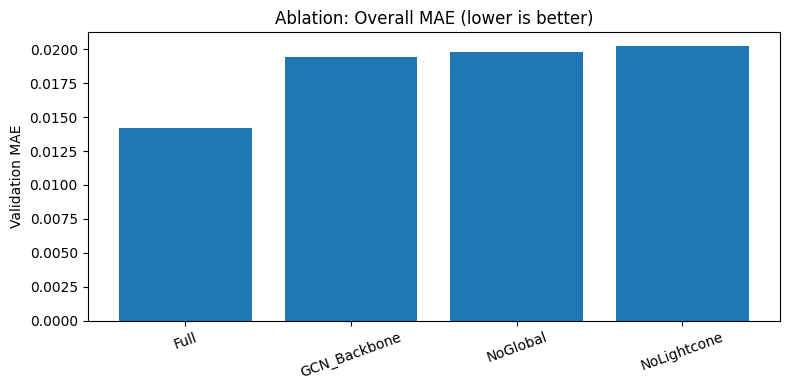

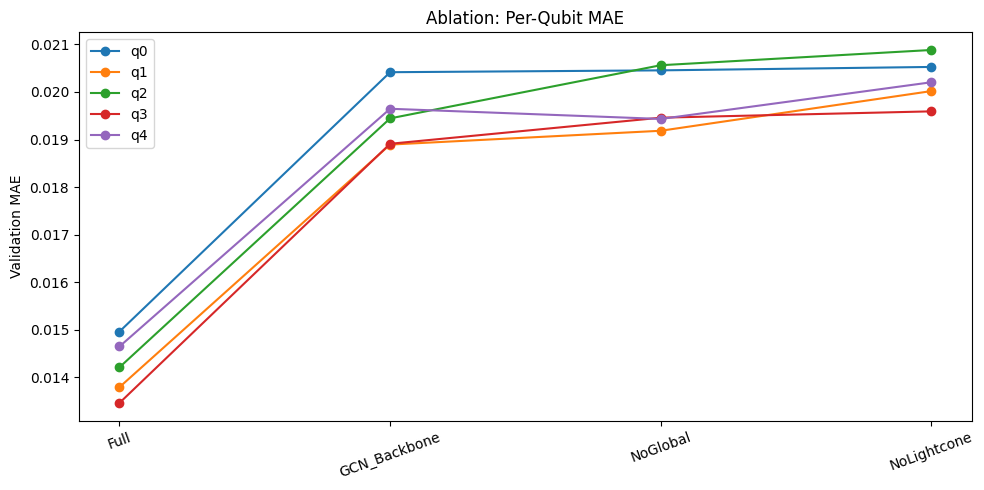

In [20]:
import matplotlib.pyplot as plt

# Overall MAE
plt.figure(figsize=(8,4))
xs = np.arange(len(df_ablate))
plt.bar(xs, df_ablate["overall_mae"].values)
plt.xticks(xs, df_ablate["variant"].tolist(), rotation=20)
plt.ylabel("Validation MAE")
plt.title("Ablation: Overall MAE (lower is better)")
plt.tight_layout()
plt.savefig("ablation-mae.png")
plt.show()

# Per-qubit MAE
plt.figure(figsize=(10,5))
for q in range(M):
    plt.plot(df_ablate["variant"], df_ablate[f"mae_q{q}"], marker="o", label=f"q{q}")
plt.ylabel("Validation MAE")
plt.title("Ablation: Per-Qubit MAE")
plt.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("ablation-qubit.png")
plt.show()
